In [1]:
import pandas as pd

summary = pd.read_csv(
    "../data/processed/johor_zoning_summary.csv"
)

summary.head(20)

,gunatanah1,daerah_nam,polygon_count
0,Infrastruktur dan Utiliti,Johor Bahru,3519
1,Industri,Kluang,2542
2,Industri,Kota Tinggi,1905
3,Infrastruktur dan Utiliti,Kluang,1127
4,Infrastruktur dan Utiliti,,925
5,Infrastruktur dan Utiliti,Segamat,571
6,Infrastruktur dan Utiliti,Muar,403
7,Infrastruktur dan Utiliti,Batu Pahat,333
8,Infrastruktur dan Utiliti,Kota Tinggi,321
9,Infrastruktur dan Utiliti,Pontian,191


In [2]:
summary[
    summary["gunatanah1"] == "Industri"
].head(20)

,gunatanah1,daerah_nam,polygon_count
1,Industri,Kluang,2542
2,Industri,Kota Tinggi,1905
10,Industri,Mersing,89
11,Industri,,60
12,Industri,Johor Bahru,45
13,Industri,Pontian,42
14,Industri,Batu Pahat,30


In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [4]:
zoning = gpd.read_parquet(
    "../data/processed/johor_relevant_zoning.parquet"
)

zoning.head()

,OBJECTID,gunatanah1,kod_gtn,tahun_data,lot_upi,luas_hekta,nama_ranca,negeri_nam,daerah_nam,mukim_name,seksyen_na,pbt_name,geometry,powerstack_source,fact_type,country,state
0,68505,Industri,TIN000,2019,3857,0.693,RT Daerah Kluang 2020,Johor,Kluang,Bandar Kluang,Tiada,Majlis Perbandaran Kluang,"POLYGON ((103.3188 2.04107, 103.31877 2.04115,...",PLANMalaysia iPLAN,VERIFIED,Malaysia,Johor
1,68711,Industri,TIN000,2019,5022,0.018,RT Daerah Kluang 2020,Johor,Kluang,Bandar Kluang,Tiada,Majlis Perbandaran Kluang,"POLYGON ((103.31938 2.04266, 103.31935 2.04272...",PLANMalaysia iPLAN,VERIFIED,Malaysia,Johor
2,68716,Industri,TIN000,2019,,0.313,RT Daerah Kluang 2020,Johor,Kluang,Bandar Kluang,Tiada,Majlis Perbandaran Kluang,"POLYGON ((103.32611 2.02074, 103.32577 2.02081...",PLANMalaysia iPLAN,VERIFIED,Malaysia,Johor
3,68758,Industri,TIN000,2019,,0.316,RT Daerah Kluang 2020,Johor,Kluang,Bandar Kluang,Tiada,Majlis Perbandaran Kluang,"POLYGON ((103.33189 2.01731, 103.33142 2.01758...",PLANMalaysia iPLAN,VERIFIED,Malaysia,Johor
4,68825,Industri,TIN000,2019,,0.225,RT Daerah Kluang 2020,Johor,Kluang,Bandar Kluang,Tiada,Majlis Perbandaran Kluang,"POLYGON ((103.32544 2.02086, 103.32525 2.02092...",PLANMalaysia iPLAN,VERIFIED,Malaysia,Johor


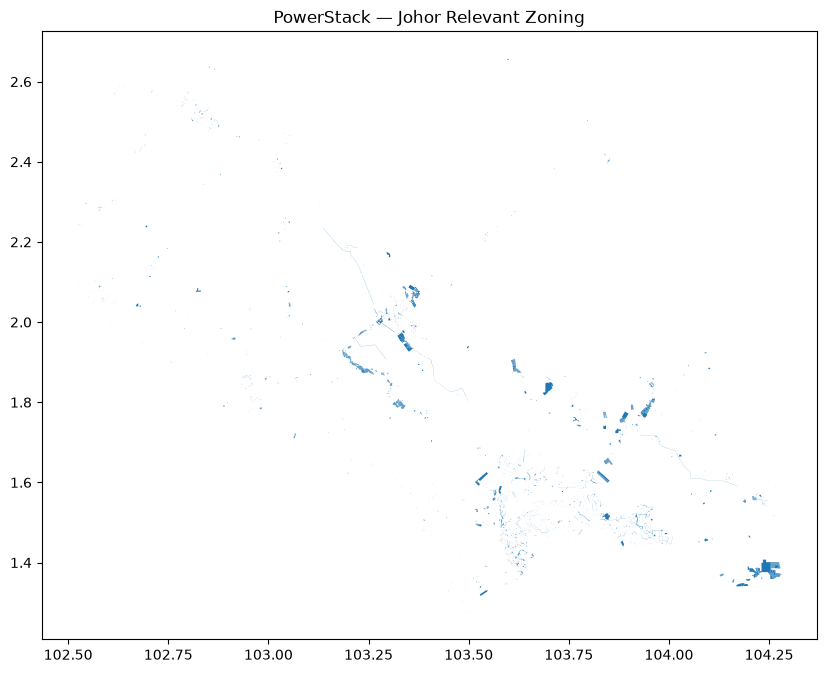

In [5]:
zoning.plot(
    figsize=(10, 12)
)

plt.title(
    "PowerStack — Johor Relevant Zoning"
)

plt.show()

In [6]:
industrial = zoning[
    zoning["gunatanah1"]
    == "Industri"
].copy()

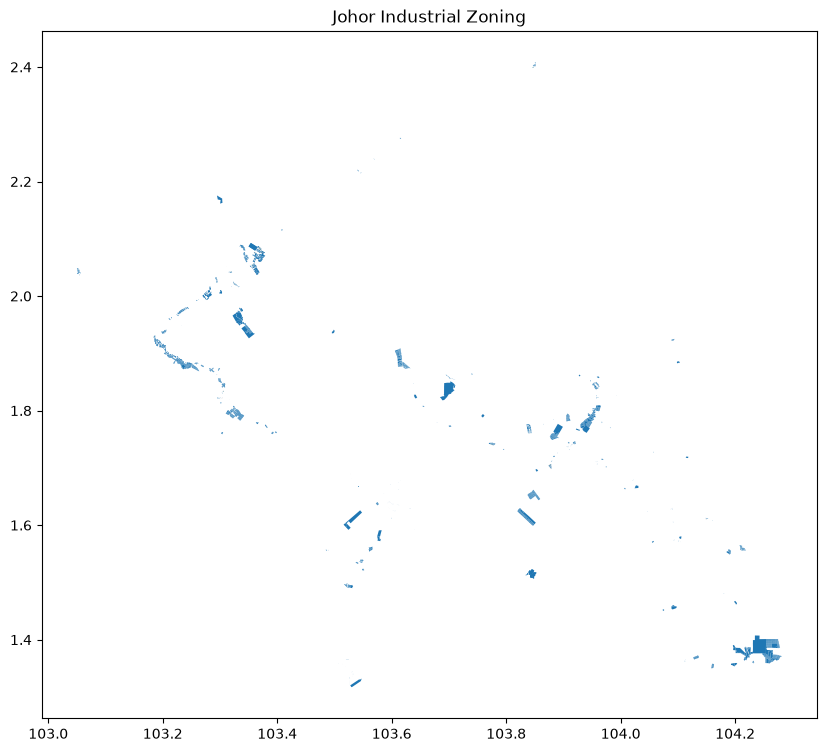

In [7]:
industrial.plot(
    figsize=(10, 12)
)

plt.title(
    "Johor Industrial Zoning"
)

plt.show()

In [8]:
industrial[
    "daerah_nam"
].value_counts()

daerah_nam
Kluang         2542
Kota Tinggi    1905
Mersing          89
                 60
Johor Bahru      45
Pontian          42
Batu Pahat       30
Name: count, dtype: int64

In [9]:
industrial[
    "mukim_name"
].value_counts().head(20)

mukim_name
Kluang                     1684
Kota Tinggi                 865
Ulu Benut                   383
Pantai Timur                352
Ulu Sungai Johor            325
Machap                      213
Tanjung Surat               140
Ulu Sungei Sedili Besar     134
Bandar Kluang               130
Rengam                      119
Mersing                      89
Pengerang                    65
                             60
Jelutong                     37
Chaah Bahru                  30
Jeram Batu                   21
Sedili Besar                 15
Serkat                       13
Plentong                      8
Johor Lama                    6
Name: count, dtype: int64

In [10]:
industrial[
    [
        "daerah_nam",
        "mukim_name",
        "pbt_name",
        "luas_hekta",
        "tahun_data",
    ]
].head(20)

,daerah_nam,mukim_name,pbt_name,luas_hekta,tahun_data
0,Kluang,Bandar Kluang,Majlis Perbandaran Kluang,0.693,2019
1,Kluang,Bandar Kluang,Majlis Perbandaran Kluang,0.018,2019
2,Kluang,Bandar Kluang,Majlis Perbandaran Kluang,0.313,2019
3,Kluang,Bandar Kluang,Majlis Perbandaran Kluang,0.316,2019
4,Kluang,Bandar Kluang,Majlis Perbandaran Kluang,0.225,2019
5,Kluang,Bandar Kluang,Majlis Perbandaran Kluang,0.018,2019
6,Kluang,Bandar Kluang,Majlis Perbandaran Kluang,0.606,2019
7,Kluang,Bandar Kluang,Majlis Perbandaran Kluang,0.096,2019
8,Kluang,Bandar Kluang,Majlis Perbandaran Kluang,0.390,2019
9,Kluang,Bandar Kluang,Majlis Perbandaran Kluang,0.318,2019


In [11]:
industrial_projected = (
    industrial
    .to_crs(
        "EPSG:3375"
    )
)

In [12]:
industrial_projected[
    "calculated_area_ha"
] = (
    industrial_projected
    .geometry
    .area
    / 10_000
)

In [14]:
industrial_projected[
    [
        "daerah_nam",
        "mukim_name",
        "luas_hekta",
        "calculated_area_ha",
    ]
].head(20)

,daerah_nam,mukim_name,luas_hekta,calculated_area_ha
0,Kluang,Bandar Kluang,0.693,0.692984
1,Kluang,Bandar Kluang,0.018,0.017870
2,Kluang,Bandar Kluang,0.313,0.313100
3,Kluang,Bandar Kluang,0.316,0.315839
4,Kluang,Bandar Kluang,0.225,0.224795
5,Kluang,Bandar Kluang,0.018,0.017807
6,Kluang,Bandar Kluang,0.606,0.606088
7,Kluang,Bandar Kluang,0.096,0.096428
8,Kluang,Bandar Kluang,0.390,0.389920
9,Kluang,Bandar Kluang,0.318,0.318328


In [15]:
large_industrial = (
    industrial_projected[
        industrial_projected[
            "calculated_area_ha"
        ] >= 10
    ]
    .copy()
)

In [16]:
len(large_industrial)

94

In [17]:
large_industrial[
    [
        "daerah_nam",
        "mukim_name",
        "pbt_name",
        "calculated_area_ha",
    ]
].sort_values(
    "calculated_area_ha",
    ascending=False,
).head(30)

,daerah_nam,mukim_name,pbt_name,calculated_area_ha
4151,Kota Tinggi,Pantai Timur,Majlis Daerah Kota Tinggi,752.259146
957,Kota Tinggi,Ulu Sungai Johor,Majlis Daerah Kota Tinggi,493.173935
1207,,,Majlis Perbandaran Kulai,259.009849
1496,Kluang,Kluang,Majlis Perbandaran Kluang,202.421465
3029,Kota Tinggi,Kota Tinggi,Majlis Daerah Kota Tinggi,190.048984
4583,Kluang,Rengam,"Majlis Daerah Simpang Renggam, Kluang",136.700660
4490,Kota Tinggi,Pengerang,Majlis Daerah Kota Tinggi,131.226087
3046,Kota Tinggi,Kota Tinggi,Majlis Daerah Kota Tinggi,122.730503
2861,Kluang,Kluang,Majlis Perbandaran Kluang,121.729174
2036,Kluang,Kluang,Majlis Perbandaran Kluang,121.729174
